In [1]:
from google.colab import files

uploaded = files.upload()


Saving Sample - Superstore.csv to Sample - Superstore.csv


In [7]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

# Load the CSV into pandas first
df = pd.read_csv("Sample - Superstore.csv", encoding="latin-1")

# Create a SQL database in memory
conn = sqlite3.connect("superstore.db")

# Push the pandas dataframe into SQL as a table called "orders"
df.to_sql("orders", conn, if_exists="replace", index=False)

# Confirm it worked
cursor = conn.cursor()
cursor.execute("SELECT COUNT(*) FROM orders")
print("Total rows loaded:", cursor.fetchone()[0])

# Preview the columns
print("\nColumns:", list(df.columns))

Total rows loaded: 9994

Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


In [8]:
query1 = """
SELECT
    Region,
    ROUND(SUM(Sales), 2) AS Total_Sales,
    ROUND(SUM(Profit), 2) AS Total_Profit,
    COUNT(*) AS Total_Orders
FROM orders
GROUP BY Region
ORDER BY Total_Sales DESC
"""

result1 = pd.read_sql_query(query1, conn)
print(result1)

    Region  Total_Sales  Total_Profit  Total_Orders
0     West    725457.82     108418.45          3203
1     East    678781.24      91522.78          2848
2  Central    501239.89      39706.36          2323
3    South    391721.91      46749.43          1620


In [9]:
query2 = """
SELECT
    Region,
    ROUND(AVG(Discount) * 100, 1) AS Avg_Discount_Pct,
    ROUND(AVG(Profit), 2) AS Avg_Profit_Per_Order
FROM orders
GROUP BY Region
ORDER BY Avg_Discount_Pct DESC
"""

result2 = pd.read_sql_query(query2, conn)
print(result2)

    Region  Avg_Discount_Pct  Avg_Profit_Per_Order
0  Central              24.0                 17.09
1    South              14.7                 28.86
2     East              14.5                 32.14
3     West              10.9                 33.85


In [10]:
query3 = """
SELECT
    Category,
    ROUND(SUM(Sales), 2) AS Total_Sales,
    ROUND(SUM(Profit), 2) AS Total_Profit,
    ROUND(SUM(Profit) * 100.0 / SUM(Sales), 1) AS Profit_Margin_Pct
FROM orders
GROUP BY Category
ORDER BY Total_Profit DESC
"""

result3 = pd.read_sql_query(query3, conn)
print(result3)

          Category  Total_Sales  Total_Profit  Profit_Margin_Pct
0       Technology    836154.03     145454.95               17.4
1  Office Supplies    719047.03     122490.80               17.0
2        Furniture    741999.80      18451.27                2.5


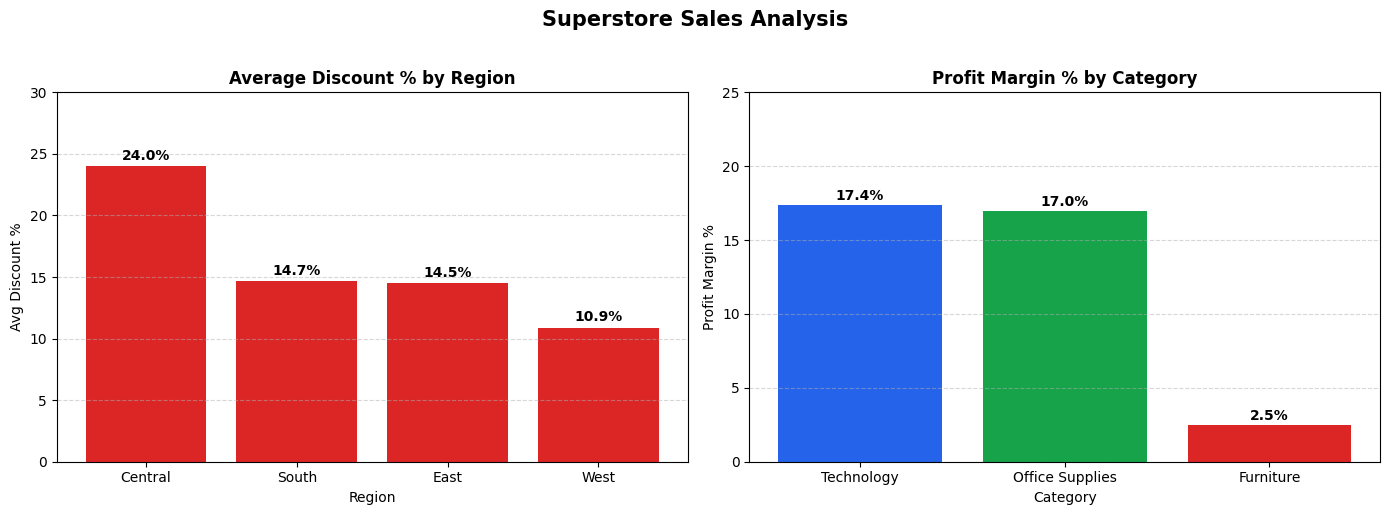

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1 — Discount vs Profit by Region
ax1.bar(result2["Region"], result2["Avg_Discount_Pct"], color="#DC2626")
ax1.set_title("Average Discount % by Region", fontweight="bold")
ax1.set_xlabel("Region")
ax1.set_ylabel("Avg Discount %")
ax1.set_ylim(0, 30)
ax1.grid(axis="y", linestyle="--", alpha=0.5)

for i, v in enumerate(result2["Avg_Discount_Pct"]):
    ax1.text(i, v + 0.5, f"{v}%", ha="center", fontweight="bold")

# Chart 2 — Profit Margin by Category
colors = ["#2563EB", "#16A34A", "#DC2626"]
ax2.bar(result3["Category"], result3["Profit_Margin_Pct"], color=colors)
ax2.set_title("Profit Margin % by Category", fontweight="bold")
ax2.set_xlabel("Category")
ax2.set_ylabel("Profit Margin %")
ax2.set_ylim(0, 25)
ax2.grid(axis="y", linestyle="--", alpha=0.5)

for i, v in enumerate(result3["Profit_Margin_Pct"]):
    ax2.text(i, v + 0.3, f"{v}%", ha="center", fontweight="bold")

plt.suptitle("Superstore Sales Analysis", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [12]:
summary = """
==============================================
   SUPERSTORE SALES ANALYSIS — FINDINGS
==============================================

Dataset: 9,994 orders | US Retail Company | 4 Regions | 3 Categories

FINDING 1 — Regional Sales vs Profit
--------------------------------------
West region leads in both sales ($725K) and profit ($108K).
Central region ranks 3rd in sales but has the LOWEST profit ($39K)
despite outselling the South by $110,000.
Conclusion: Central is the least profitable region in the company.

FINDING 2 — Root Cause: Over-Discounting in Central
-----------------------------------------------------
Central gives an average discount of 24% per order — more than
double the West region's 10.9%. This directly results in Central
making only $17 profit per order vs West's $34.
Conclusion: Reducing discounts in Central could double profit per order.

FINDING 3 — Category Profitability
------------------------------------
Technology has the highest profit margin at 17.4%, followed closely
by Office Supplies at 17.0%. Furniture sells $742K but only returns
a 2.5% margin — the lowest by far.
Conclusion: Furniture requires urgent investigation. Technology and
Office Supplies are the company's most efficient revenue streams.

==============================================
Tools used: Python, pandas, SQLite, matplotlib
Certificate applied: IBM Data Analyst Professional Certificate (Coursera)
==============================================
"""

print(summary)


   SUPERSTORE SALES ANALYSIS — FINDINGS

Dataset: 9,994 orders | US Retail Company | 4 Regions | 3 Categories

FINDING 1 — Regional Sales vs Profit
--------------------------------------
West region leads in both sales ($725K) and profit ($108K).
Central region ranks 3rd in sales but has the LOWEST profit ($39K)
despite outselling the South by $110,000.
Conclusion: Central is the least profitable region in the company.

FINDING 2 — Root Cause: Over-Discounting in Central
-----------------------------------------------------
Central gives an average discount of 24% per order — more than
double the West region's 10.9%. This directly results in Central
making only $17 profit per order vs West's $34.
Conclusion: Reducing discounts in Central could double profit per order.

FINDING 3 — Category Profitability
------------------------------------
Technology has the highest profit margin at 17.4%, followed closely
by Office Supplies at 17.0%. Furniture sells $742K but only returns
a 2.5% marg